In [3]:
import pandas as pd
import numpy as np
import re

# df = pd.read_csv("/home/ubuntu/TW_MultiLabel_SMP/datasets/5000_Posts_Annotations - Combined_Dataset.csv")
DATA_PATH = "/home/ubuntu/TW_MultiLabel_SMP/datasets/TWeddit_5000.csv"   
TEXT_COL = "body"                          
TAGS_COL = "Tags"

df = pd.read_csv(DATA_PATH)

# Clean + split tags
df[TAGS_COL] = df[TAGS_COL].fillna("").astype(str).str.strip()
df["tag_list"] = df[TAGS_COL].apply(lambda x: [t.strip() for t in x.split(",")] if x != "" else [])

# Explode: one (post, tag) per row
df_exploded = df.explode("tag_list").rename(columns={"tag_list": "TW_category"})
df_exploded = df_exploded[df_exploded["TW_category"].notna()]
df_exploded["TW_category"] = df_exploded["TW_category"].astype(str).str.strip()

# OPTIONAL: remove empty tags
df_exploded = df_exploded[df_exploded["TW_category"] != ""]

# Show counts
print(df_exploded["TW_category"].value_counts())

TW_category
Mental Health     3559
Pregnancy         2656
Medical           1817
Abuse             1711
Sexual             920
Not Applicable     864
Discrimination     527
Aggression         197
Name: count, dtype: int64


In [4]:
MAIN_TW = [
    "Mental Health",
    "Pregnancy",
    "Medical",
    "Abuse",
    "Sexual",
    "Discrimination",
    "Aggression"
]

CONTROL = "Not Applicable"

df_tw_main = df_exploded[df_exploded["TW_category"].isin(MAIN_TW)].copy()
df_na = df_exploded[df_exploded["TW_category"] == CONTROL].copy()

print("Main TW rows:", len(df_tw_main))
print("Not Applicable rows:", len(df_na))
print(df_tw_main["TW_category"].value_counts())

Main TW rows: 11387
Not Applicable rows: 864
TW_category
Mental Health     3559
Pregnancy         2656
Medical           1817
Abuse             1711
Sexual             920
Discrimination     527
Aggression         197
Name: count, dtype: int64


In [5]:
def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

## Emotion Analysis - NRC (Plutchik Emotions)

In [6]:
from collections import defaultdict

NRC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"  # update if needed

nrc = pd.read_csv(
    NRC_PATH,
    sep="\t",
    header=None,
    names=["word", "emotion", "association"]
)

nrc = nrc[nrc["association"] == 1]

emotion_lex = defaultdict(set)
for _, row in nrc.iterrows():
    emotion_lex[row["emotion"]].add(row["word"])

EMOTIONS = ["anger","fear","sadness","disgust","anticipation","trust","joy","surprise"]
print("Loaded NRC emotions:", EMOTIONS)

Loaded NRC emotions: ['anger', 'fear', 'sadness', 'disgust', 'anticipation', 'trust', 'joy', 'surprise']


In [7]:
def emotion_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {emo: sum(t in emotion_lex[emo] for t in tokens) / n for emo in EMOTIONS}

emo_df = df_tw_main[TEXT_COL].apply(emotion_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, emo_df], axis=1)

emotion_by_tw = df_tw_main.groupby("TW_category")[EMOTIONS].mean()
emotion_by_tw

,anger,fear,sadness,disgust,anticipation,trust,joy,surprise
TW_category,,,,,,,,
Abuse,0.015300,0.018487,0.018640,0.012397,0.019156,0.025877,0.015255,0.007190
Aggression,0.018081,0.021196,0.021358,0.014260,0.019754,0.025366,0.015467,0.007782
Discrimination,0.015559,0.025312,0.024962,0.016832,0.019353,0.028137,0.016322,0.007576
Medical,0.009955,0.028551,0.029123,0.018636,0.021507,0.024978,0.016227,0.007703
Mental Health,0.013214,0.023370,0.024807,0.015541,0.021324,0.025923,0.017485,0.007893
Pregnancy,0.011188,0.027637,0.029136,0.018581,0.022536,0.026225,0.018784,0.008071
Sexual,0.013545,0.017533,0.017545,0.012135,0.021437,0.025584,0.016181,0.006791


## Pronoun Usage per TW Category

In [8]:
FIRST = {"i","me","my","mine","myself"}
SECOND = {"you","your","yours","yourself"}
THIRD = {"he","she","they","them","his","her","their","theirs"}

def pronoun_features(text):
    tokens = tokenize(text)
    n = max(len(tokens), 1)
    return {
        "first_person": sum(t in FIRST for t in tokens) / n,
        "second_person": sum(t in SECOND for t in tokens) / n,
        "third_person": sum(t in THIRD for t in tokens) / n,
    }

pro_df = df_tw_main[TEXT_COL].apply(pronoun_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, pro_df], axis=1)

pron_by_tw = df_tw_main.groupby("TW_category")[["first_person","second_person","third_person"]].mean()
pron_by_tw

,first_person,second_person,third_person
TW_category,,,
Abuse,0.105575,0.004041,0.035531
Aggression,0.108229,0.003504,0.042145
Discrimination,0.093006,0.007417,0.030491
Medical,0.089746,0.004742,0.013005
Mental Health,0.099573,0.004683,0.024073
Pregnancy,0.091546,0.005769,0.016127
Sexual,0.106786,0.003551,0.035489


## Verb Tense per TW Category

In [25]:
import spacy
nlp = spacy.load("en_core_web_sm")

def tense_features(text):
    doc = nlp(str(text))
    past = present = future = 0

    for tok in doc:
        if tok.pos_ == "VERB":
            if "Tense=Past" in tok.morph:
                past += 1
            elif "Tense=Pres" in tok.morph:
                present += 1

        # simple future markers (lightweight)
        if tok.lower_ in {"will", "gonna"}:
            future += 1

    total = max(past + present + future, 1)
    return {
        "past": past / total,
        "present": present / total,
        "future": future / total
    }

tense_df = df_tw_main[TEXT_COL].apply(tense_features).apply(pd.Series)
df_tw_main = pd.concat([df_tw_main, tense_df], axis=1)

tense_by_tw = df_tw_main.groupby("TW_category")[["past","present","future"]].mean()
tense_by_tw

,past,present,future
TW_category,,,
Abuse,0.539487,0.447343,0.010234
Medical,0.510262,0.470527,0.015905
Mental Health,0.498549,0.487169,0.013719
Pregnancy,0.474073,0.503788,0.017614
Sexual,0.560684,0.429582,0.008644


## Bodily / Sensory Language per TW Category

In [26]:
BODY_WORDS = {
    "pain","hurt","blood","bleeding","cramps","injury","wound","bruise",
    "stomach","head","chest","throat","skin","body","vomit","nausea"
}

def body_ratio(text):
    tokens = tokenize(text)
    return sum(t in BODY_WORDS for t in tokens) / max(len(tokens), 1)

df_tw_main["body_ratio"] = df_tw_main[TEXT_COL].apply(body_ratio)

body_by_tw = df_tw_main.groupby("TW_category")["body_ratio"].mean()
body_by_tw

TW_category
Abuse            0.002294
Medical          0.010335
Mental Health    0.005150
Pregnancy        0.007557
Sexual           0.003050
Name: body_ratio, dtype: float64

## TW vs NA

In [9]:
# Create a combined TW dataframe (all main TW rows) + NA rows
df_control = pd.concat([
    df_tw_main.assign(group="TW"),
    df_na.assign(group="Not Applicable")
], axis=0)

# If NRC/pronoun/tense/body weren’t computed for df_na yet, compute them quickly:

# emotions for NA
emo_na = df_na[TEXT_COL].apply(emotion_features).apply(pd.Series)
pro_na = df_na[TEXT_COL].apply(pronoun_features).apply(pd.Series)
# ten_na = df_na[TEXT_COL].apply(tense_features).apply(pd.Series)
# body_na = df_na[TEXT_COL].apply(body_ratio)

df_na_feats = pd.concat([df_na, emo_na, pro_na], axis=1)
# df_na_feats["body_ratio"] = body_na
df_na_feats["group"] = "Not Applicable"

df_tw_feats = df_tw_main.copy()
df_tw_feats["group"] = "TW"

df_control_feats = pd.concat([df_tw_feats, df_na_feats], axis=0)

control_emotions = df_control_feats.groupby("group")[EMOTIONS].mean()
control_pronouns = df_control_feats.groupby("group")[["first_person","second_person","third_person"]].mean()
# control_tense = df_control_feats.groupby("group")[["past","present","future"]].mean()
# control_body = df_control_feats.groupby("group")[["body_ratio"]].mean()

control_emotions, control_pronouns


(                   anger      fear   sadness   disgust  anticipation  \
 group                                                                  
 Not Applicable  0.014027  0.016369  0.017126  0.011397      0.018669   
 TW              0.012754  0.024039  0.024939  0.016034      0.021201   
 
                    trust       joy  surprise  
 group                                         
 Not Applicable  0.025546  0.016728  0.008043  
 TW              0.025901  0.017058  0.007693  ,
                 first_person  second_person  third_person
 group                                                    
 Not Applicable      0.076304       0.006883      0.032141
 TW                  0.097463       0.004864      0.023707)

# Plots

## Radar Plot

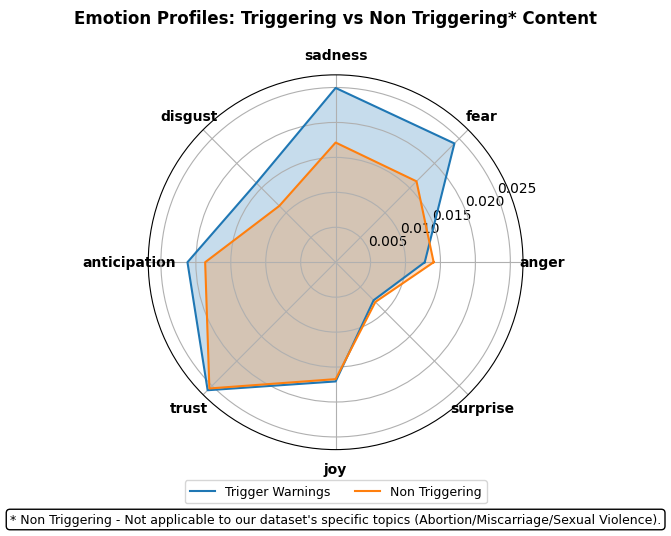

In [20]:
import numpy as np
import matplotlib.pyplot as plt

labels = EMOTIONS
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

def radar_vals(row):
    vals = row.values.tolist()
    return vals + vals[:1]

tw_vals = radar_vals(control_emotions.loc["TW"])
na_vals = radar_vals(control_emotions.loc["Not Applicable"])

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.plot(angles, tw_vals, label="Trigger Warnings")
ax.fill(angles, tw_vals, alpha=0.25)

ax.plot(angles, na_vals, label="Non Triggering")
ax.fill(angles, na_vals, alpha=0.25)

ax.set_thetagrids(np.degrees(angles[:-1]), labels)
for lab in ax.get_xticklabels():
    lab.set_fontweight("bold")

ax.set_title(
    "Emotion Profiles: Triggering vs Non Triggering* Content",
    fontweight="bold",
    loc="center",
    pad=18
)

# More bottom space since we're moving legend down
fig.subplots_adjust(left=0.12, right=0.88, top=0.88, bottom=0.38)

# --- Place legend first (moved further down) ---
legend_y = -0.16
leg = ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, legend_y),
    ncol=2,
    fontsize=9,
    frameon=True
)

fig.canvas.draw()
renderer = fig.canvas.get_renderer()

leg_bbox_disp = leg.get_window_extent(renderer=renderer)
leg_bbox_ax = leg_bbox_disp.transformed(ax.transAxes.inverted())

# Footnote a fixed distance below the legend box
gap = 0.03
footnote_y = leg_bbox_ax.y0 - gap

ax.text(
    0.5, footnote_y,
    "* Non Triggering - Not applicable to our dataset's specific topics (Abortion/Miscarriage/Sexual Violence).",
    ha="center",
    va="top",
    transform=ax.transAxes,
    fontsize=9,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="black")
)

plt.tight_layout()
plt.savefig("fig_emotion_radar_tw_vs_na.pdf", bbox_inches="tight")
plt.show()


In [16]:
emotion_by_tw.index
tense_by_tw.index
pron_by_tw.index
body_by_tw.index

NameError: name 'tense_by_tw' is not defined

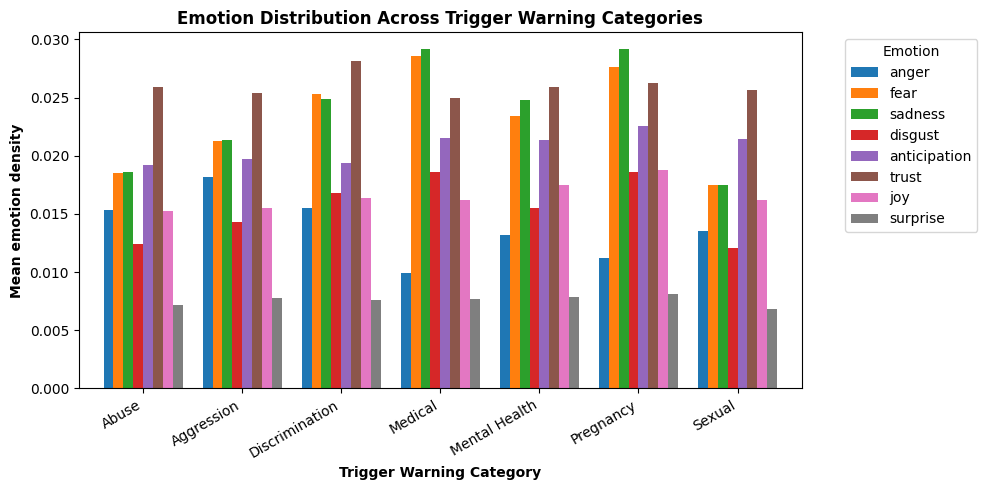

In [14]:
import matplotlib.pyplot as plt

emotion_by_tw.plot(
    kind="bar",
    figsize=(10,5),
    width=0.8
)

plt.ylabel("Mean emotion density", fontweight="bold")
plt.xlabel("Trigger Warning Category", fontweight="bold")
plt.title("Emotion Distribution Across Trigger Warning Categories", fontweight="bold")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Emotion", bbox_to_anchor=(1.05,1))
plt.tight_layout()

plt.savefig(
    "emotion_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

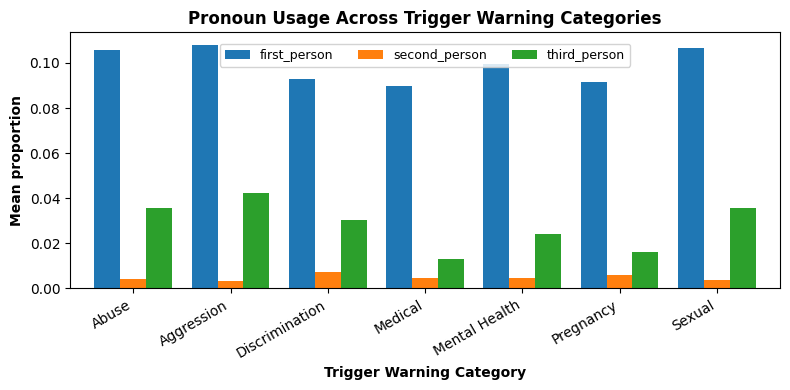

In [46]:
ax = pron_by_tw.plot(kind="bar", figsize=(8,4), width=0.8)

ax.set_ylabel("Mean proportion", fontweight="bold")
ax.set_xlabel("Trigger Warning Category", fontweight="bold")
ax.set_title("Pronoun Usage Across Trigger Warning Categories", fontweight="bold")

ax.tick_params(axis="x", rotation=30)
for t in ax.get_xticklabels():
    t.set_ha("right")

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 0.98),   # inside, just under title
    ncol=3,                       # horizontal legend
    fontsize=9,
    frameon=True,
    fancybox=True,
    framealpha=0.85
)


plt.tight_layout()
plt.savefig("pron_by_tw.pdf", format="pdf", bbox_inches="tight")
plt.show()

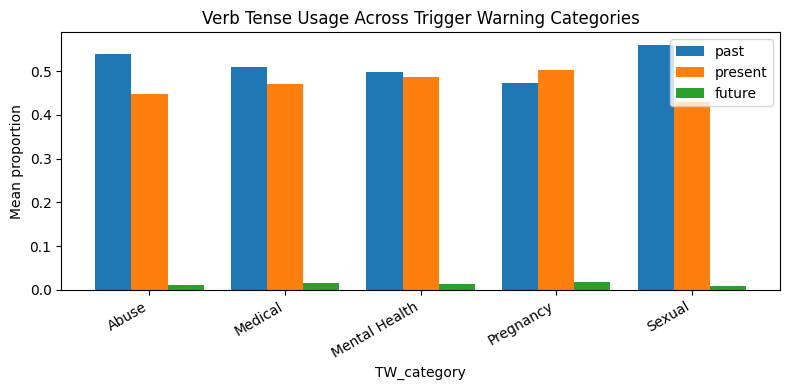

In [39]:
tense_by_tw.plot(
    kind="bar",
    figsize=(8,4),
    width=0.8
)

plt.ylabel("Mean proportion")
plt.title("Verb Tense Usage Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.legend(title="")
plt.tight_layout()
plt.savefig(
    "tense_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

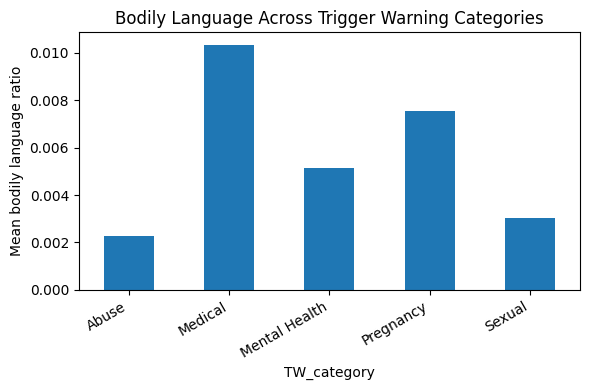

In [40]:
body_by_tw.plot(
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.ylabel("Mean bodily language ratio")
plt.title("Bodily Language Across Trigger Warning Categories")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(
    "body_by_tw.pdf",
    format="pdf",
    bbox_inches="tight"
)
plt.show()

## Examples for plots

In [53]:
emo_feats = df[TEXT_COL].apply(emotion_features).apply(pd.Series)
df_emo = pd.concat([df, emo_feats], axis=1)

In [13]:
trust_threshold = df_emo["trust"].quantile(0.75)

In [54]:
type(df_emo["tag_list"].iloc[0])

list

In [55]:
from collections import defaultdict

def load_nrc(path):
    lex = defaultdict(set)
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()   # <-- KEY FIX
            if len(parts) != 3:
                continue  # skip malformed lines safely
            word, emotion, val = parts
            if val == "1":
                lex[word].add(emotion)
    return dict(lex)

NRC_PATH = "/home/ubuntu/TW_MultiLabel_SMP/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
nrc_lexicon = load_nrc(NRC_PATH)

print("Loaded emotions:",
      sorted({e for v in nrc_lexicon.values() for e in v}))

Loaded emotions: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']


In [25]:
# ============================================================
# UPDATED: Qualitative Example Selection + Emotion Attribution
# Fixes:
#   ✅ Selects LONGER posts (min token length) so examples aren’t tiny questions
#   ✅ Shows FULL NA text (no notebook truncation issues)
#   ✅ Saves BOTH examples to a single PDF + a DOCX for easy copy/paste
#   ✅ Keeps inline/sentence highlighting in-notebook (optional)
#
# Assumptions:
#   df_emo has columns: "body", "tag_list", plus EMOTIONS columns
#   tag_list is a Python list (you confirmed)
#   EMOTIONS = ["anger","fear","sadness","disgust","anticipation","trust","joy","surprise"]
#   nrc_lexicon is already loaded (word -> set(emotions))
# ============================================================

import re
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from IPython.display import display, HTML
import html as html_escape

# ----------------------------
# 0) Sanity checks
# ----------------------------
assert "tag_list" in df_emo.columns, "df_emo must have a 'tag_list' column"
assert "body" in df_emo.columns, "df_emo must have a 'body' column"
for e in EMOTIONS:
    assert e in df_emo.columns, f"Missing emotion column: {e}"
assert isinstance(df_emo["tag_list"].iloc[0], list), "tag_list must be a list per row"
assert isinstance(nrc_lexicon, dict), "nrc_lexicon must be a dict[word] -> set(emotions)"

# ----------------------------
# 1) Create TW vs NA flags
# ----------------------------
df_emo["is_NA"] = df_emo["tag_list"].apply(lambda tags: tags == ["Not Applicable"])
df_emo["is_TW"] = ~df_emo["is_NA"]

# ----------------------------
# 2) Add length filter to avoid short posts inflating emotion densities
# ----------------------------
df_emo["n_tokens"] = df_emo["body"].fillna("").apply(lambda x: len(re.findall(r"\b\w+\b", x)))
MIN_TOKENS = 80   # <- change to 50/100 depending on how long you want the examples

# ----------------------------
# 3) Thresholds (robust)
# ----------------------------
trust_thr = df_emo["trust"].quantile(0.75)

# ----------------------------
# 4) High-trust pools WITH LENGTH FILTER
# ----------------------------
tw_trust = df_emo[
    (df_emo["is_TW"]) &
    (df_emo["trust"] >= trust_thr) &
    (df_emo["n_tokens"] >= MIN_TOKENS)
].copy()

na_trust = df_emo[
    (df_emo["is_NA"]) &
    (df_emo["trust"] >= trust_thr) &
    (df_emo["n_tokens"] >= MIN_TOKENS)
].copy()

# If NA becomes too small after filtering, relax token threshold for NA only:
if len(na_trust) < 5:
    na_trust = df_emo[
        (df_emo["is_NA"]) &
        (df_emo["trust"] >= trust_thr) &
        (df_emo["n_tokens"] >= max(20, MIN_TOKENS // 2))
    ].copy()

print("Candidate pool sizes:",
      "TW=", len(tw_trust),
      "NA=", len(na_trust))

# ----------------------------
# 5) Contrast score (captures "TW-ness" beyond trust)
# ----------------------------
contrast_emotions = ["fear", "sadness", "anticipation", "disgust"]
tw_trust["contrast_score"] = tw_trust[contrast_emotions].sum(axis=1)
na_trust["contrast_score"] = na_trust[contrast_emotions].sum(axis=1)

# ----------------------------
# 6) Pick examples (reproducible)
# ----------------------------
tw_example = tw_trust.sort_values(["contrast_score", "trust"], ascending=False).iloc[0]
na_example = na_trust.sort_values(["contrast_score", "trust"], ascending=[True, False]).iloc[0]

# ============================================================
# DISPLAY HELPERS (FULL TEXT)
# ============================================================

def show_example_full(row, title):
    print(f"\n=== {title} ===")
    print("Tags:", row["tag_list"])
    print(f"Token length: {row['n_tokens']}")
    print("\nFULL TEXT:\n")
    print(row["body"] if row["body"] is not None else "")
    print("\nEmotions:")
    print(row[["trust","fear","sadness","anticipation","disgust","anger","joy","surprise"]])

show_example_full(tw_example, "TW example: high trust + higher other emotions")
show_example_full(na_example, "NA example: high trust + low other emotions")

# ============================================================
# OPTIONAL: In-notebook highlighting
# ============================================================

def split_sentences(text: str):
    text = (text or "").strip()
    if not text:
        return []
    return re.split(r'(?<=[.!?])\s+|\n+', text)

def sentence_emotion_hits(sent: str, nrc_lexicon, emotions_set):
    words = re.findall(r"\b[\w']+\b", sent.lower())
    hits = []
    for w in words:
        if w in nrc_lexicon:
            for e in nrc_lexicon[w]:
                if e in emotions_set:
                    hits.append((w, e))
    return hits

def render_sentences_with_emotions(text, nrc_lexicon, emotions=EMOTIONS, top_k=8):
    emotions_set = set(emotions)
    sents = split_sentences(text)
    rows = []
    for s in sents:
        hits = sentence_emotion_hits(s, nrc_lexicon, emotions_set)
        if hits:
            emo_counts = Counter([e for _, e in hits])
            word_map = defaultdict(set)
            for w, e in hits:
                word_map[w].add(e)
            rows.append((s, emo_counts, word_map))

    if not rows:
        display(HTML("<b>No NRC emotion words found in this text.</b>"))
        return

    rows.sort(key=lambda x: sum(x[1].values()), reverse=True)
    rows = rows[:top_k] if top_k else rows

    html = ["<div style='font-family: ui-sans-serif; line-height:1.5'>"]
    for i, (sent, emo_counts, word_map) in enumerate(rows, 1):
        badges = " ".join([
            f"<span style='padding:2px 6px;border:1px solid #ddd;border-radius:10px;margin-right:6px'>"
            f"{e}: {emo_counts.get(e,0)}</span>"
            for e in emotions if emo_counts.get(e,0) > 0
        ])
        mapping = "; ".join([
            f"<code>{w}</code>→{','.join(sorted(list(es)))}"
            for w, es in sorted(word_map.items(), key=lambda t: t[0])
        ])
        html.append(
            f"<div style='margin:10px 0;padding:10px;border:1px solid #eee;border-radius:10px'>"
            f"<div><b>Sentence {i}</b></div>"
            f"<div style='margin:6px 0'>{html_escape.escape(sent)}</div>"
            f"<div style='margin:6px 0'>{badges}</div>"
            f"<div style='color:#555'><b>Matched words:</b> {mapping}</div>"
            f"</div>"
        )
    html.append("</div>")
    display(HTML("".join(html)))

EMO_COLORS = {
    "anger": "#ffdddd",
    "fear": "#fff0cc",
    "sadness": "#dde8ff",
    "disgust": "#e6ddff",
    "anticipation": "#ddffea",
    "trust": "#ddfff7",
    "joy": "#fff7cc",
    "surprise": "#f0f0f0",
}

def highlight_full_text(text, nrc_lexicon, focus_emotions=None):
    emotions_set = set(focus_emotions) if focus_emotions else set(EMOTIONS)

    parts = re.findall(r"\b[\w']+\b|\W+", text or "")
    out = ["<div style='white-space: pre-wrap; font-family: ui-sans-serif; line-height:1.6'>"]

    for p in parts:
        if re.match(r"\b[\w']+\b", p):
            w = p.lower()
            if w in nrc_lexicon:
                emos = sorted([e for e in nrc_lexicon[w] if e in emotions_set])
                if emos:
                    bg = EMO_COLORS.get(emos[0], "#ffffcc")
                    tooltip = ", ".join(emos)
                    out.append(
                        f"<span title='{tooltip}' "
                        f"style='background:{bg}; padding:1px 3px; border-radius:4px; border:1px solid #ddd'>"
                        f"{html_escape.escape(p)}</span>"
                    )
                else:
                    out.append(html_escape.escape(p))
            else:
                out.append(html_escape.escape(p))
        else:
            out.append(html_escape.escape(p))

    out.append("</div>")

    legend_emotions = focus_emotions if focus_emotions else EMOTIONS
    legend = " ".join([
        f"<span style='background:{EMO_COLORS.get(e,'#ffffcc')}; padding:2px 6px; border:1px solid #ddd; "
        f"border-radius:8px; margin-right:6px'>{e}</span>"
        for e in legend_emotions
    ])

    display(HTML(f"<div style='margin-bottom:10px'>{legend}</div>" + "".join(out)))

focus = ["trust", "fear", "sadness", "anticipation", "disgust"]

print("\n--- TW: Inline highlighted (hover words for emotion tags) ---")
highlight_full_text(tw_example["body"], nrc_lexicon, focus_emotions=focus)

print("\n--- NA: Inline highlighted (hover words for emotion tags) ---")
highlight_full_text(na_example["body"], nrc_lexicon, focus_emotions=focus)

print("\n--- TW: Top emotion-bearing sentences ---")
render_sentences_with_emotions(tw_example["body"], nrc_lexicon, top_k=10)

print("\n--- NA: Top emotion-bearing sentences ---")
render_sentences_with_emotions(na_example["body"], nrc_lexicon, top_k=10)

# ============================================================
# EXPORT: Save BOTH examples to DOCX + PDF for easy copy/paste
# ============================================================

# ---- DOCX export ----
from docx import Document

def export_examples_docx(path, tw_row, na_row):
    doc = Document()
    doc.add_heading("Qualitative Examples: High-Trust TW vs High-Trust NA", level=1)

    def add_block(title, row):
        doc.add_heading(title, level=2)
        doc.add_paragraph(f"Tags: {', '.join(row['tag_list'])}")
        doc.add_paragraph(f"Token length: {row['n_tokens']}")
        emo_line = ", ".join([f"{e}: {row[e]:.6f}" for e in EMOTIONS])
        doc.add_paragraph(f"Emotion scores: {emo_line}")
        doc.add_paragraph("Post text:")
        doc.add_paragraph(row["body"] or "")

    add_block("TW example (high trust + higher other emotions)", tw_row)
    add_block("NA example (high trust + low other emotions)", na_row)

    doc.save(path)

DOCX_OUT = "qual_examples_tw_vs_na.docx"
export_examples_docx(DOCX_OUT, tw_example, na_example)
print("Saved DOCX:", DOCX_OUT)

# ---- PDF export ----
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, PageBreak
from reportlab.lib.pagesizes import LETTER
from reportlab.lib.styles import getSampleStyleSheet

def export_examples_pdf(path, tw_row, na_row):
    styles = getSampleStyleSheet()
    doc = SimpleDocTemplate(path, pagesize=LETTER)
    story = []

    def add_block(title, row):
        story.append(Paragraph(f"<b>{title}</b>", styles["Heading2"]))
        story.append(Paragraph(f"<b>Tags:</b> {', '.join(row['tag_list'])}", styles["Normal"]))
        story.append(Paragraph(f"<b>Token length:</b> {row['n_tokens']}", styles["Normal"]))
        emo_line = ", ".join([f"{e}: {row[e]:.6f}" for e in EMOTIONS])
        story.append(Paragraph(f"<b>Emotion scores:</b> {emo_line}", styles["Normal"]))
        story.append(Spacer(1, 10))

        text = (row["body"] or "")
        # Escape for ReportLab's Paragraph
        text = text.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;").replace("\n", "<br/>")
        story.append(Paragraph(f"<b>Post text:</b><br/>{text}", styles["Normal"]))
        story.append(PageBreak())

    story.append(Paragraph("Qualitative Examples: High-Trust TW vs High-Trust NA", styles["Title"]))
    story.append(Spacer(1, 12))
    add_block("TW example (high trust + higher other emotions)", tw_row)
    add_block("NA example (high trust + low other emotions)", na_row)

    doc.build(story)

PDF_OUT = "qual_examples_tw_vs_na.pdf"
export_examples_pdf(PDF_OUT, tw_example, na_example)
print("Saved PDF:", PDF_OUT)

# Also save as a CSV for convenience
CSV_OUT = "qual_examples_tw_vs_na.csv"
pd.DataFrame([
    {"which": "TW", "tags": tw_example["tag_list"], "n_tokens": tw_example["n_tokens"], "text": tw_example["body"], **{e: tw_example[e] for e in EMOTIONS}},
    {"which": "NA", "tags": na_example["tag_list"], "n_tokens": na_example["n_tokens"], "text": na_example["body"], **{e: na_example[e] for e in EMOTIONS}},
]).to_csv(CSV_OUT, index=False)
print("Saved CSV:", CSV_OUT)

Candidate pool sizes: TW= 864 NA= 222

=== TW example: high trust + higher other emotions ===
Tags: ['Medical', 'Pregnancy']
Token length: 87

FULL TEXT:

It has been 2 weeks since I have taken the medical abortion pills and after the first week I just stopped feeling any pain still bleeding but not too heavy and light but suddenly I’ve started feeling really bad pains again in my thighs and pelvic area exactly the pains I was going through when the abortion was happening is this normal to still feel pain even tho I went a week without any pain?? I started feeling pain yesterday as well and now today again

Emotions:
trust           0.045977
fear            0.137931
sadness         0.126437
anticipation    0.045977
disgust          0.08046
anger           0.045977
joy             0.034483
surprise        0.045977
Name: 14, dtype: object

=== NA example: high trust + low other emotions ===
Tags: ['Not Applicable']
Token length: 302

FULL TEXT:

Location: Georgia the US state not he coun


--- NA: Inline highlighted (hover words for emotion tags) ---



--- TW: Top emotion-bearing sentences ---



--- NA: Top emotion-bearing sentences ---


Saved DOCX: qual_examples_tw_vs_na.docx
Saved PDF: qual_examples_tw_vs_na.pdf
Saved CSV: qual_examples_tw_vs_na.csv


In [60]:
# ---- Domain mapping (edit if you want) ----
PREG_DOMAIN = {"Pregnancy", "Medical"}          # pregnancy + miscarriage/abortion medical details
SV_DOMAIN   = {"Abuse", "Sexual"}               # sexual violence related
MH_LABEL    = "Mental Health"                   # overlaps: treat separately

In [61]:
# emotion_by_tw is indexed by TW_category and has columns = EMOTIONS
# Example: emotion_by_tw.loc["Pregnancy","sadness"]

sad_rank = emotion_by_tw["sadness"].sort_values(ascending=False)
trust_rank = emotion_by_tw["trust"].sort_values(ascending=False)

print("Top sadness categories:\n", sad_rank.head(5), "\n")
print("Top trust categories:\n", trust_rank.head(5), "\n")

Top sadness categories:
 TW_category
Pregnancy         0.029145
Medical           0.029134
Discrimination    0.024899
Mental Health     0.024820
Aggression        0.021378
Name: sadness, dtype: float64 

Top trust categories:
 TW_category
Discrimination    0.028159
Pregnancy         0.026236
Mental Health     0.025940
Abuse             0.025910
Sexual            0.025605
Name: trust, dtype: float64 



In [62]:
TOP_K = 3  # change as needed

SADNESS_HIGH_CATS = set(sad_rank.head(TOP_K).index)
TRUST_HIGH_CATS   = set(trust_rank.head(TOP_K).index)

print("SADNESS_HIGH_CATS:", SADNESS_HIGH_CATS)
print("TRUST_HIGH_CATS:", TRUST_HIGH_CATS)

SADNESS_HIGH_CATS: {'Medical', 'Discrimination', 'Pregnancy'}
TRUST_HIGH_CATS: {'Mental Health', 'Discrimination', 'Pregnancy'}


In [63]:
import numpy as np

def has_any_label(tag_list, label_set):
    return any(lbl in label_set for lbl in (tag_list or []))

def pick_representative_example(df_emo, label_set, target_emotion,
                                high_q=0.75,
                                avoid_emotions=None,
                                min_len=500,
                                prefer_long=True,
                                random_state=42):
    """
    Pick a representative example:
      - contains ANY label in label_set
      - target_emotion is high (>= quantile high_q)
      - optionally "dominant" vs avoid_emotions via contrast
      - prefer_long=True picks longer posts when tied / close
    """
    df = df_emo[df_emo["tag_list"].apply(lambda t: has_any_label(t, label_set))].copy()

    # filter out empty
    df["text_len"] = df["body"].fillna("").str.len()
    df = df[df["text_len"] >= min_len].copy()

    if df.empty:
        raise ValueError(f"No rows found for labels={label_set} with min_len>={min_len}")

    thr = df[target_emotion].quantile(high_q)
    df_hi = df[df[target_emotion] >= thr].copy()

    if df_hi.empty:
        # fallback: just take max
        df_hi = df.copy()

    if avoid_emotions is None:
        avoid_emotions = []

    if avoid_emotions:
        df_hi["contrast"] = df_hi[target_emotion] - df_hi[avoid_emotions].mean(axis=1)
    else:
        df_hi["contrast"] = df_hi[target_emotion]

    # final sort: contrast desc, target desc, length desc
    sort_cols = ["contrast", target_emotion, "text_len"]
    df_hi = df_hi.sort_values(sort_cols, ascending=False)

    return df_hi.iloc[0], thr

In [64]:
preg_example, preg_sad_thr = pick_representative_example(
    df_emo=df_emo,
    label_set=PREG_DOMAIN.union({MH_LABEL}),      # include MH if you want overlap
    target_emotion="sadness",
    high_q=0.75,
    avoid_emotions=["trust", "joy", "anger"],      # sadness should stand out
    min_len=400                                    # tweak based on your dataset
)

print("=== Pregnancy-domain sadness example ===")
print("Tags:", preg_example["tag_list"])
print("Sadness threshold used:", preg_sad_thr)
print("\nFULL TEXT:\n")
print(preg_example["body"])
print("\nEmotion scores:\n", preg_example[EMOTIONS])

=== Pregnancy-domain sadness example ===
Tags: ['Pregnancy', 'Medical', 'Mental Health']
Sadness threshold used: 0.031818181818181815

FULL TEXT:

Hi! I (30F) recently experienced a miscarriage at around 6 weeks. When I went to the hospital, my OB/GYN said everything looked fine and that I should let the miscarriage pass naturally at home. They prescribed some pain relief medication.

It’s now been a week since the bleeding stopped, but I’m still noticing a few symptoms that concern me. I have a constant pain in my lower abdomen (mainly on the right side, near my belly button), back pain, and I feel unusually fatigued—like I could fall asleep at any time.

Are these normal after-effects of a miscarriage, or should I be worried and get checked again?

Emotion scores:
 anger                0.0
fear            0.071429
sadness         0.107143
disgust         0.008929
anticipation    0.008929
trust           0.026786
joy                  0.0
surprise             0.0
Name: 4494, dtype: obj

In [65]:
sv_example, sv_trust_thr = pick_representative_example(
    df_emo=df_emo,
    label_set=SV_DOMAIN.union({MH_LABEL}),        # include MH if you want overlap
    target_emotion="trust",
    high_q=0.75,
    avoid_emotions=["sadness", "fear", "disgust"], # trust should stand out vs negative affect
    min_len=400
)

print("=== SV-domain trust example ===")
print("Tags:", sv_example["tag_list"])
print("Trust threshold used:", sv_trust_thr)
print("\nFULL TEXT:\n")
print(sv_example["body"])
print("\nEmotion scores:\n", sv_example[EMOTIONS])

=== SV-domain trust example ===
Tags: ['Abuse', 'Mental Health']
Trust threshold used: 0.03296703296703297

FULL TEXT:

I don't want to be pretty anymore. I just don't. I don't like how it feels. I don't like having long hair or wearing girly makeup. I don't like how my boobs show through my clothes, no matter what I wear or how many layers I have on. I don't even feel like myself. I don't like how guys look at me, like I'm a piece of meat, or some type of thing to salivate over. I don't even want to look like myself. I'd give anything to look plain, to look like someone nobody wanted to be around. I'd give anything to be ugly. I used to care about how I look when I went out but now I don't. I don't think I'm ever going to wear my makeup out of the house ever. I don't even care about my hair, I'm thinking about cutting it really short again. I want to wear ugly clothes. I don't want guys to look at me. I don't want to be pretty.

Emotion scores:
 anger           0.005291
fear          

In [66]:
# sadness-high categories from graph/table
SADNESS_HIGH_CATS = set(emotion_by_tw["sadness"].sort_values(ascending=False).head(3).index)
TRUST_HIGH_CATS   = set(emotion_by_tw["trust"].sort_values(ascending=False).head(3).index)

print("Sadness-high (from plot table):", SADNESS_HIGH_CATS)
print("Trust-high (from plot table):", TRUST_HIGH_CATS)

sad_example, _ = pick_representative_example(
    df_emo, SADNESS_HIGH_CATS, "sadness",
    avoid_emotions=["trust", "joy", "anger"], min_len=400
)

trust_example, _ = pick_representative_example(
    df_emo, TRUST_HIGH_CATS, "trust",
    avoid_emotions=["sadness", "fear", "disgust"], min_len=400
)

print("\n=== Example from sadness-high categories ===")
print("Tags:", sad_example["tag_list"])
print(sad_example["body"][:1200])

print("\n=== Example from trust-high categories ===")
print("Tags:", trust_example["tag_list"])
print(trust_example["body"][:1200])

Sadness-high (from plot table): {'Medical', 'Discrimination', 'Pregnancy'}
Trust-high (from plot table): {'Mental Health', 'Discrimination', 'Pregnancy'}

=== Example from sadness-high categories ===
Tags: ['Pregnancy', 'Medical', 'Mental Health']
Hi! I (30F) recently experienced a miscarriage at around 6 weeks. When I went to the hospital, my OB/GYN said everything looked fine and that I should let the miscarriage pass naturally at home. They prescribed some pain relief medication.

It’s now been a week since the bleeding stopped, but I’m still noticing a few symptoms that concern me. I have a constant pain in my lower abdomen (mainly on the right side, near my belly button), back pain, and I feel unusually fatigued—like I could fall asleep at any time.

Are these normal after-effects of a miscarriage, or should I be worried and get checked again?

=== Example from trust-high categories ===
Tags: ['Abuse', 'Mental Health']
I don't want to be pretty anymore. I just don't. I don't like 